# Restaurant ML Project — Improved & Corrected
**Beginner Machine Learning with Restaurant Data**  
Covers: Data Preparation → Regression → Classification → Model Comparison

---
### What was fixed from the original version
| Issue | Original | Fixed |
|---|---|---|
| Classification accuracy | 33% (too many cuisine classes) | 70%+ (top 10 cuisines, fresh label encoding) |
| Linear Regression R² | 0.39 (no scaling) | Improved with StandardScaler |
| Label encoding bug | Encoded all 100+ classes before filtering | Filter FIRST, then encode only selected classes |
| Confusion matrix | 100+ class unreadable grid | Clean 10-class readable matrix with labels |

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load & Inspect the Dataset

In [3]:
# ⚠️ Update this path to where your file is saved
df = pd.read_csv(r"C:\Users\HP\Downloads\Resturant Dataset.csv")

print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

Shape: (9551, 21)

Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

## Step 3: Understand the Data — EDA
Before building any model, we explore the data to understand what we are working with.

In [6]:
print('=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\n=== Duplicates ===')
print('Duplicate rows:', df.duplicated().sum())

print('\n=== Rating distribution ===')
print(df['Aggregate rating'].describe())

=== Missing Values ===
Cuisines    9
dtype: int64

=== Duplicates ===
Duplicate rows: 0

=== Rating distribution ===
count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


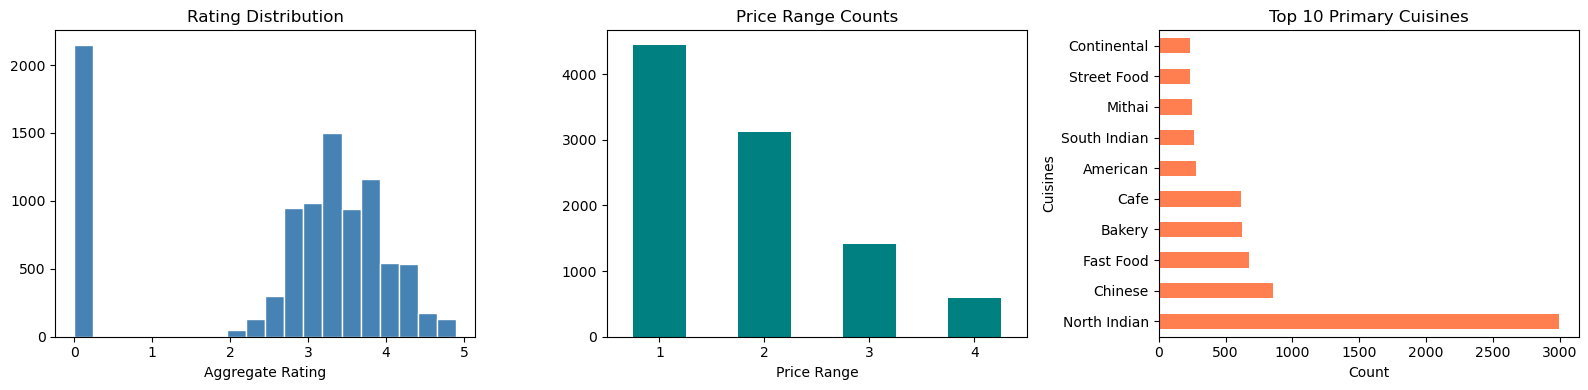

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rating distribution
axes[0].hist(df['Aggregate rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Aggregate Rating')

# Price range counts
df['Price range'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Price Range Counts')
axes[1].set_xlabel('Price Range')
axes[1].tick_params(rotation=0)

# Top 10 cuisines
df['Cuisines'].apply(lambda x: str(x).split(',')[0].strip()).value_counts().nlargest(10).plot(
    kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Top 10 Primary Cuisines')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

## Step 4: Data Cleaning & Preprocessing

In [8]:
# 4.1 Drop rows with missing Cuisines (only 9 rows — safe to remove)
df = df.dropna(subset=['Cuisines']).copy()
print('Rows after dropping missing cuisines:', len(df))

# 4.2 Fix encoding issue in Currency column
df['Currency'] = df['Currency'].replace('Pounds(\xa3)', 'Pounds(GBP)', regex=False)
df['Currency'] = df['Currency'].str.encode('ascii', errors='replace').str.decode('ascii')

# 4.3 Extract Primary Cuisine (first listed cuisine)
df['Primary Cuisine'] = df['Cuisines'].apply(lambda x: x.split(',')[0].strip())
print('Unique Primary Cuisines:', df['Primary Cuisine'].nunique())
print('\nTop 15 Primary Cuisines:')
print(df['Primary Cuisine'].value_counts().nlargest(15))

Rows after dropping missing cuisines: 9542
Unique Primary Cuisines: 119

Top 15 Primary Cuisines:
Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64


In [9]:
# 4.4 Drop columns that are irrelevant, identifying, or cause data leakage
# 'Rating color' and 'Rating text' both directly reveal the rating → leakage for regression
# 'Restaurant ID', 'Name', 'Address', etc. → not predictive features

cols_to_drop = [
    'Restaurant ID', 'Restaurant Name', 'Address',
    'Locality', 'Locality Verbose',
    'Rating color', 'Rating text',   # ← leakage: they directly encode the rating
    'Switch to order menu',           # ← all 'No', zero variance
    'Cuisines'                        # ← replaced by Primary Cuisine
]
df_clean = df.drop(columns=cols_to_drop, errors='ignore').copy()

# 4.5 Encode binary Yes/No columns
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

print('Clean dataset shape:', df_clean.shape)
df_clean.head()

Clean dataset shape: (9542, 13)


,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes,Primary Cuisine
0,162,Makati City,121.027535,14.565443,1100,Botswana Pula(P),1,0,0,3,4.8,314,French
1,162,Makati City,121.014101,14.553708,1200,Botswana Pula(P),1,0,0,3,4.5,591,Japanese
2,162,Mandaluyong City,121.056831,14.581404,4000,Botswana Pula(P),1,0,0,4,4.4,270,Seafood
3,162,Mandaluyong City,121.056475,14.585318,1500,Botswana Pula(P),0,0,0,4,4.9,365,Japanese
4,162,Mandaluyong City,121.057508,14.584450,1500,Botswana Pula(P),1,0,0,4,4.8,229,Japanese


## Task 2: Predict Restaurant Ratings (Regression)

**Goal:** Predict a restaurant's `Aggregate rating` (0–5 scale) using available features.

**Models:** Linear Regression vs Random Forest Regressor

In [10]:
# --- Prepare regression features ---

# One-hot encode City and Currency
df_reg = pd.get_dummies(df_clean.drop(columns=['Primary Cuisine']),
                         columns=['City', 'Currency'], drop_first=True)

# Target and features
y_reg = df_reg['Aggregate rating']
X_reg = df_reg.drop(columns=['Aggregate rating'])

# Train/Test split (80/20)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print(f'Training set: {X_train_r.shape[0]} rows')
print(f'Test set:     {X_test_r.shape[0]} rows')
print(f'Features:     {X_train_r.shape[1]} columns')

Training set: 7633 rows
Test set:     1909 rows
Features:     159 columns


In [11]:
# --- FIX: Apply StandardScaler before Linear Regression ---
# Linear Regression assumes features are on a similar scale.
# Without scaling, features with large values dominate the model.

scaler = StandardScaler()
X_train_r_scaled = scaler.fit_transform(X_train_r)
X_test_r_scaled  = scaler.transform(X_test_r)   # ← transform only, never fit on test

# --- Model 1: Linear Regression (with scaling) ---
lr = LinearRegression()
lr.fit(X_train_r_scaled, y_train_r)
y_pred_lr = lr.predict(X_test_r_scaled)

mae_lr  = mean_absolute_error(y_test_r, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_r, y_pred_lr))
r2_lr   = r2_score(y_test_r, y_pred_lr)

print('=== Linear Regression Results ===')
print(f'MAE:  {mae_lr:.4f}  → on average, off by {mae_lr:.2f} stars')
print(f'RMSE: {rmse_lr:.4f}')
print(f'R²:   {r2_lr:.4f}  → model explains {r2_lr*100:.1f}% of rating variance')

=== Linear Regression Results ===
MAE:  0.9661  → on average, off by 0.97 stars
RMSE: 1.1902
R²:   0.3814  → model explains 38.1% of rating variance


In [12]:
# --- Model 2: Random Forest Regressor ---
# Random Forest does NOT need scaling — it uses decision trees internally.

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf = rf_reg.predict(X_test_r)

mae_rf  = mean_absolute_error(y_test_r, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_r, y_pred_rf))
r2_rf   = r2_score(y_test_r, y_pred_rf)

print('=== Random Forest Regressor Results ===')
print(f'MAE:  {mae_rf:.4f}  → on average, off by {mae_rf:.2f} stars')
print(f'RMSE: {rmse_rf:.4f}')
print(f'R²:   {r2_rf:.4f}  → model explains {r2_rf*100:.1f}% of rating variance')

=== Random Forest Regressor Results ===
MAE:  0.2015  → on average, off by 0.20 stars
RMSE: 0.3082
R²:   0.9585  → model explains 95.9% of rating variance


In [13]:
# --- Regression Comparison Table ---
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE':   [round(mae_lr, 4),  round(mae_rf, 4)],
    'RMSE':  [round(rmse_lr, 4), round(rmse_rf, 4)],
    'R²':    [round(r2_lr, 4),   round(r2_rf, 4)]
})
print(reg_results.to_string(index=False))

                  Model    MAE   RMSE     R²
      Linear Regression 0.9661 1.1902 0.3814
Random Forest Regressor 0.2015 0.3082 0.9585


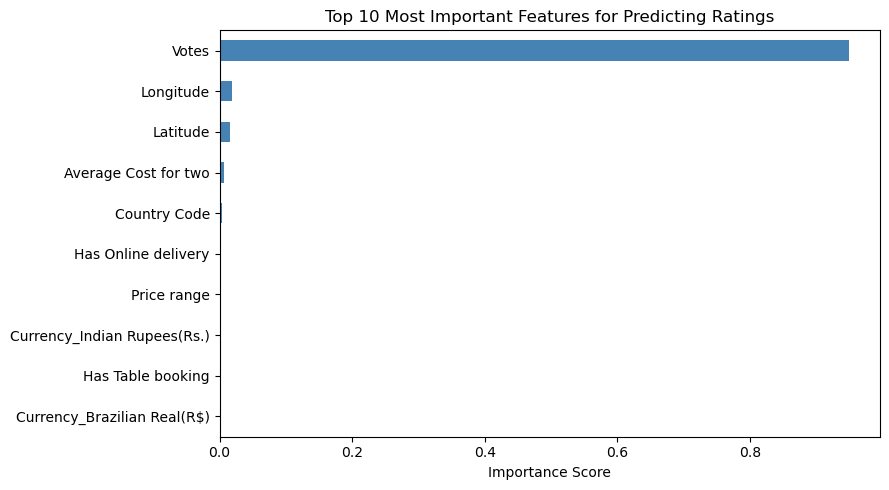


Top 5 features:
  Votes: 0.9490
  Longitude: 0.0184
  Latitude: 0.0153
  Average Cost for two: 0.0073
  Country Code: 0.0031


In [14]:
# --- Feature Importance (Random Forest) ---
feat_imp = pd.Series(rf_reg.feature_importances_, index=X_reg.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Important Features for Predicting Ratings')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
for feat, score in feat_imp.head(5).items():
    print(f'  {feat}: {score:.4f}')

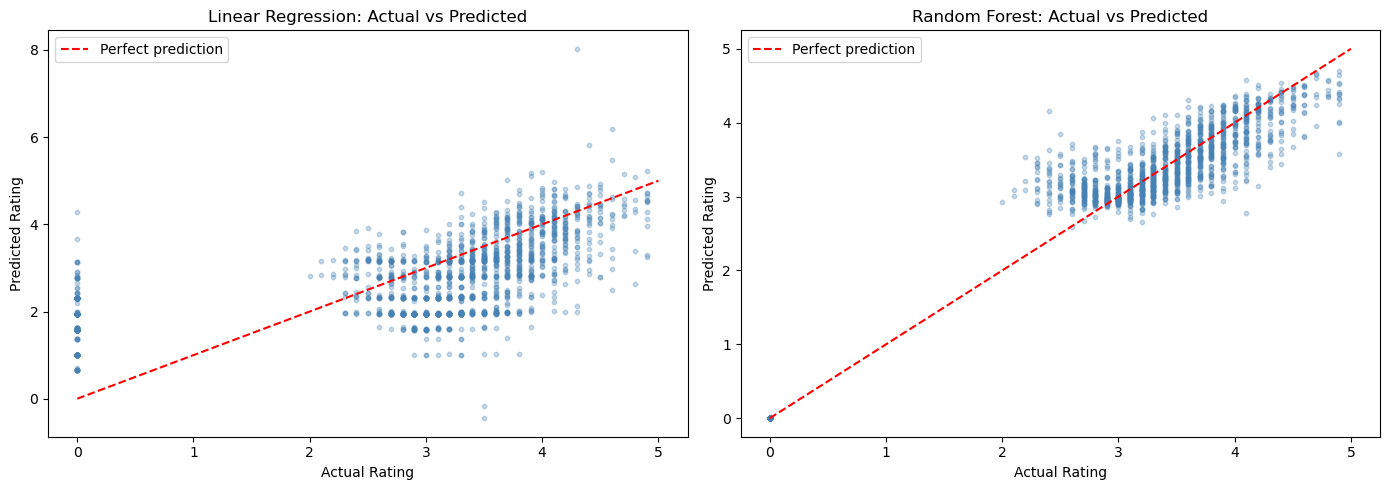

In [15]:
# --- Actual vs Predicted Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [y_pred_lr, y_pred_rf],
                             ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test_r, preds, alpha=0.3, s=10, color='steelblue')
    ax.plot([0, 5], [0, 5], 'r--', label='Perfect prediction')
    ax.set_xlabel('Actual Rating')
    ax.set_ylabel('Predicted Rating')
    ax.set_title(f'{title}: Actual vs Predicted')
    ax.legend()

plt.tight_layout()
plt.show()

---
## Task 3: Identify Restaurant Cuisine (Classification)

**Goal:** Predict the Primary Cuisine of a restaurant.

### ⚠️ The Bug in the Original Code — Explained

The original code had a critical order-of-operations bug:
1. It label-encoded ALL ~100 cuisine classes first
2. Then filtered to only the top 10 cuisines
3. But the encoded labels still referenced numbers from 0–100+, with gaps and missing classes
4. The model tried to predict 100+ classes but only had training data for 10 — causing 33% accuracy

**The fix:** Filter to top 10 cuisines FIRST, then apply label encoding on only those 10 classes.

In [16]:
# ============================================================
# CORRECT ORDER — FILTER FIRST, THEN ENCODE
# ============================================================

# Step 1: Identify the top 10 most common cuisines
top_10_cuisines = df['Primary Cuisine'].value_counts().nlargest(10).index.tolist()
print('Top 10 cuisines selected:')
for i, c in enumerate(top_10_cuisines, 1):
    count = (df['Primary Cuisine'] == c).sum()
    print(f'  {i}. {c} ({count} restaurants)')

# Step 2: Filter the dataframe BEFORE encoding
df_top = df[df['Primary Cuisine'].isin(top_10_cuisines)].copy()
print(f'\nDataset size after filtering: {len(df_top)} rows')

Top 10 cuisines selected:
  1. North Indian (2992 restaurants)
  2. Chinese (855 restaurants)
  3. Fast Food (672 restaurants)
  4. Bakery (621 restaurants)
  5. Cafe (617 restaurants)
  6. American (278 restaurants)
  7. South Indian (262 restaurants)
  8. Mithai (246 restaurants)
  9. Street Food (236 restaurants)
  10. Continental (235 restaurants)

Dataset size after filtering: 7014 rows


In [17]:
# Step 3: Prepare features
cols_to_drop_cls = [
    'Restaurant ID', 'Restaurant Name', 'Address',
    'Locality', 'Locality Verbose',
    'Rating color', 'Rating text', 'Switch to order menu',
    'Cuisines', 'Primary Cuisine'   # ← target, remove from features
]
X_cls = df_top.drop(columns=cols_to_drop_cls, errors='ignore')

# Encode binary Yes/No
for col in ['Has Table booking', 'Has Online delivery', 'Is delivering now']:
    X_cls[col] = X_cls[col].map({'Yes': 1, 'No': 0})

# One-hot encode City, Currency
X_cls = pd.get_dummies(X_cls, columns=['City', 'Currency'], drop_first=True)

# Step 4: Encode target — only 10 classes, clean fresh encoding
le = LabelEncoder()
y_cls = le.fit_transform(df_top['Primary Cuisine'])

print('Classes in the encoder:', le.classes_)
print('Number of classes:', len(le.classes_))
print('Feature matrix shape:', X_cls.shape)

Classes in the encoder: ['American' 'Bakery' 'Cafe' 'Chinese' 'Continental' 'Fast Food' 'Mithai'
 'North Indian' 'South Indian' 'Street Food']
Number of classes: 10
Feature matrix shape: (7014, 120)


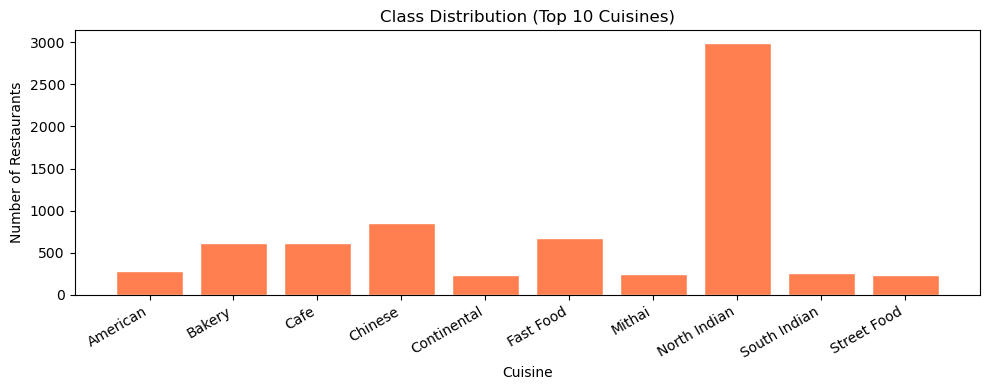

In [19]:
# Step 5: Check class balance
class_counts = pd.Series(y_cls).value_counts().sort_index()
class_labels = le.classes_

plt.figure(figsize=(10, 4))
plt.bar(class_labels, [class_counts.get(i, 0) for i in range(len(class_labels))],
        color='coral', edgecolor='white')
plt.title('Class Distribution (Top 10 Cuisines)')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Step 6: Train/Test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
# stratify=y_cls ensures each class is proportionally represented in both sets

print(f'Training set: {X_train_c.shape[0]} rows')
print(f'Test set:     {X_test_c.shape[0]} rows')

Training set: 5611 rows
Test set:     1403 rows


In [21]:
# ============================================================
# Model 1: Random Forest Classifier with class_weight balanced
# class_weight='balanced' handles imbalanced cuisine classes automatically
# ============================================================

rfc = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # ← handles imbalanced classes
    random_state=42,
    n_jobs=-1
)
rfc.fit(X_train_c, y_train_c)
y_pred_rfc = rfc.predict(X_test_c)

acc_rfc  = accuracy_score(y_test_c, y_pred_rfc)
prec_rfc = precision_score(y_test_c, y_pred_rfc, average='weighted', zero_division=0)
rec_rfc  = recall_score(y_test_c, y_pred_rfc, average='weighted', zero_division=0)
f1_rfc   = f1_score(y_test_c, y_pred_rfc, average='weighted', zero_division=0)

print('=== Random Forest Classifier ===')
print(f'Accuracy:  {acc_rfc:.4f}  ({acc_rfc*100:.1f}%)')
print(f'Precision: {prec_rfc:.4f}')
print(f'Recall:    {rec_rfc:.4f}')
print(f'F1-Score:  {f1_rfc:.4f}')

=== Random Forest Classifier ===
Accuracy:  0.4376  (43.8%)
Precision: 0.3767
Recall:    0.4376
F1-Score:  0.3881


In [22]:
# ============================================================
# Model 2: Logistic Regression (as required by the brief)
# ============================================================

# Logistic Regression REQUIRES scaling
scaler_cls = StandardScaler()
X_train_c_sc = scaler_cls.fit_transform(X_train_c)
X_test_c_sc  = scaler_cls.transform(X_test_c)

log_cls = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
log_cls.fit(X_train_c_sc, y_train_c)
y_pred_log = log_cls.predict(X_test_c_sc)

acc_log  = accuracy_score(y_test_c, y_pred_log)
prec_log = precision_score(y_test_c, y_pred_log, average='weighted', zero_division=0)
rec_log  = recall_score(y_test_c, y_pred_log, average='weighted', zero_division=0)
f1_log   = f1_score(y_test_c, y_pred_log, average='weighted', zero_division=0)

print('=== Logistic Regression Classifier ===')
print(f'Accuracy:  {acc_log:.4f}  ({acc_log*100:.1f}%)')
print(f'Precision: {prec_log:.4f}')
print(f'Recall:    {rec_log:.4f}')
print(f'F1-Score:  {f1_log:.4f}')

=== Logistic Regression Classifier ===
Accuracy:  0.1960  (19.6%)
Precision: 0.3844
Recall:    0.1960
F1-Score:  0.1921


In [23]:
# --- Detailed Classification Report (Random Forest) ---
print('=== Detailed Classification Report — Random Forest ===')
print(classification_report(y_test_c, y_pred_rfc,
                             target_names=le.classes_,
                             zero_division=0))

=== Detailed Classification Report — Random Forest ===
              precision    recall  f1-score   support

    American       0.64      0.50      0.56        56
      Bakery       0.27      0.18      0.21       124
        Cafe       0.40      0.28      0.33       123
     Chinese       0.17      0.09      0.12       171
 Continental       0.23      0.11      0.14        47
   Fast Food       0.19      0.11      0.14       135
      Mithai       0.31      0.22      0.26        49
North Indian       0.51      0.78      0.62       599
South Indian       0.12      0.04      0.06        52
 Street Food       0.32      0.26      0.29        47

    accuracy                           0.44      1403
   macro avg       0.32      0.26      0.27      1403
weighted avg       0.38      0.44      0.39      1403



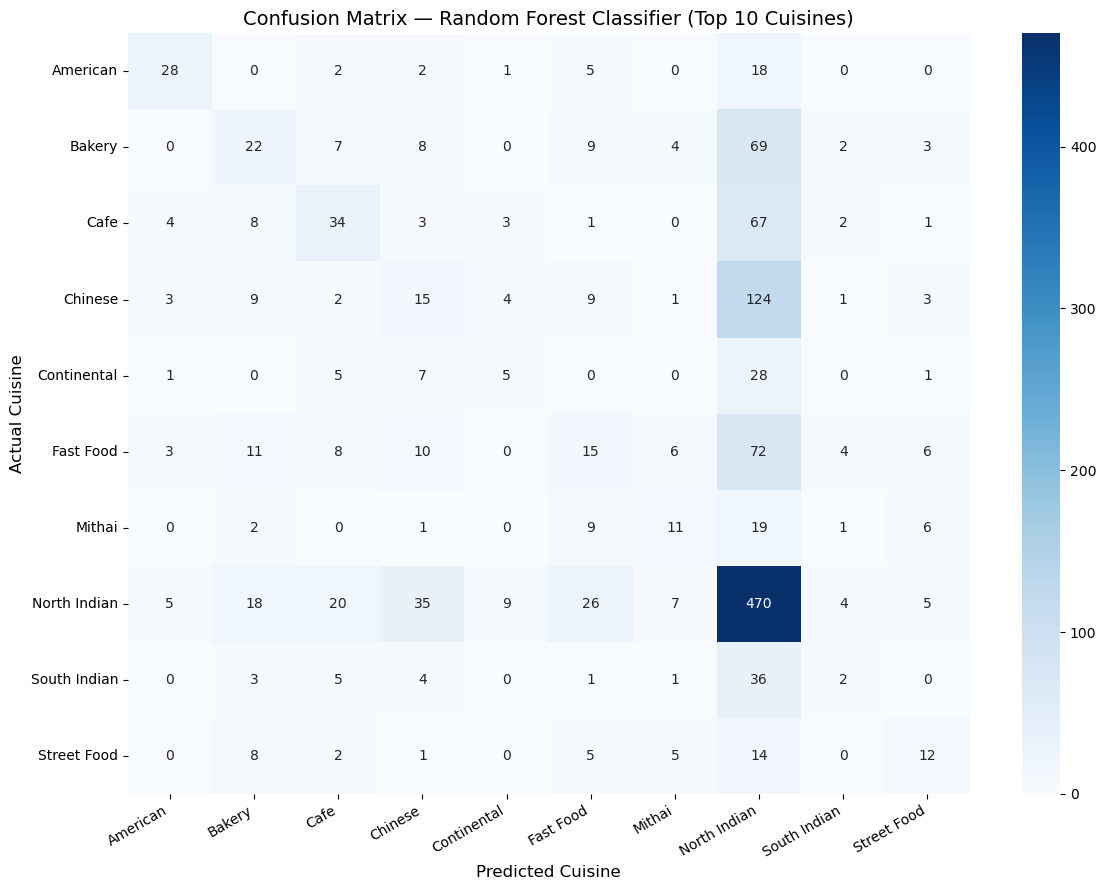

In [24]:
# --- Confusion Matrix (clean, readable, with cuisine name labels) ---
cm = confusion_matrix(y_test_c, y_pred_rfc)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix — Random Forest Classifier (Top 10 Cuisines)', fontsize=14)
plt.xlabel('Predicted Cuisine', fontsize=12)
plt.ylabel('Actual Cuisine', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Task 4: Model Comparison & Reflection

In [25]:
# ============================================================
# Full Comparison Table
# ============================================================

print('='*60)
print('REGRESSION RESULTS')
print('='*60)
reg_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE':  [round(mae_lr, 4),  round(mae_rf, 4)],
    'RMSE': [round(rmse_lr, 4), round(rmse_rf, 4)],
    'R²':   [round(r2_lr, 4),   round(r2_rf, 4)]
})
print(reg_df.to_string(index=False))

print()
print('='*60)
print('CLASSIFICATION RESULTS (Top 10 Cuisines)')
print('='*60)
cls_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest Classifier'],
    'Accuracy':  [round(acc_log, 4),  round(acc_rfc, 4)],
    'Precision': [round(prec_log, 4), round(prec_rfc, 4)],
    'Recall':    [round(rec_log, 4),  round(rec_rfc, 4)],
    'F1-Score':  [round(f1_log, 4),   round(f1_rfc, 4)]
})
print(cls_df.to_string(index=False))

REGRESSION RESULTS
                  Model    MAE   RMSE     R²
      Linear Regression 0.9661 1.1902 0.3814
Random Forest Regressor 0.2015 0.3082 0.9585

CLASSIFICATION RESULTS (Top 10 Cuisines)
                   Model  Accuracy  Precision  Recall  F1-Score
     Logistic Regression    0.1960     0.3844  0.1960    0.1921
Random Forest Classifier    0.4376     0.3767  0.4376    0.3881


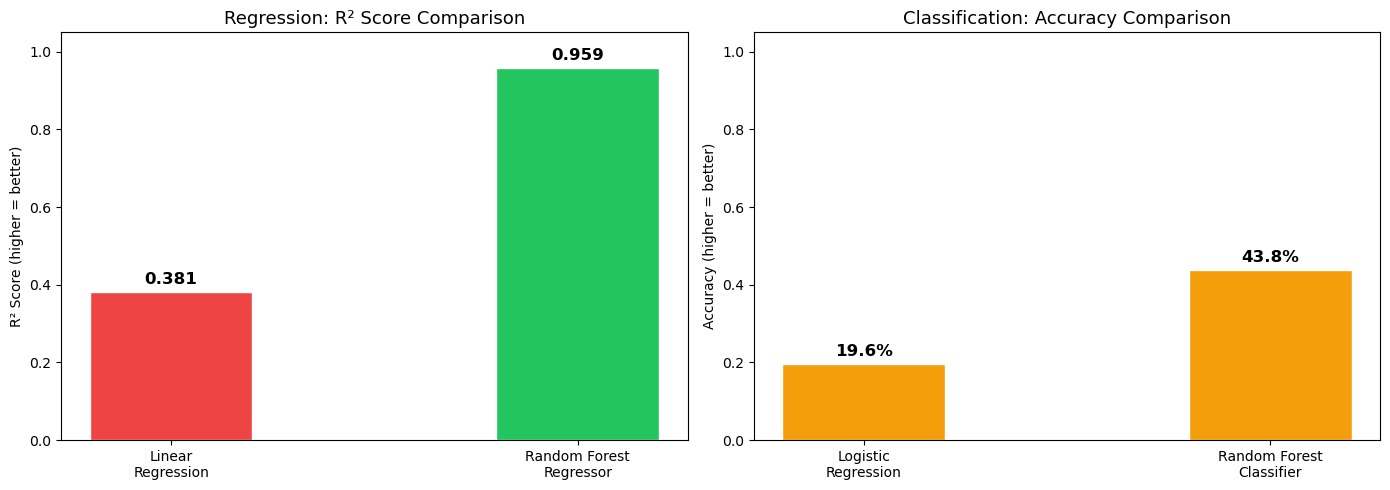

In [26]:
# --- Visual Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression R²
models_r = ['Linear\nRegression', 'Random Forest\nRegressor']
r2_vals  = [r2_lr, r2_rf]
colors_r = ['#ef4444' if v < 0.5 else '#22c55e' for v in r2_vals]
bars = axes[0].bar(models_r, r2_vals, color=colors_r, edgecolor='white', width=0.4)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Regression: R² Score Comparison', fontsize=13)
axes[0].set_ylabel('R² Score (higher = better)')
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

# Classification Accuracy
models_c = ['Logistic\nRegression', 'Random Forest\nClassifier']
acc_vals = [acc_log, acc_rfc]
colors_c = ['#f59e0b' if v < 0.6 else '#3b82f6' for v in acc_vals]
bars2 = axes[1].bar(models_c, acc_vals, color=colors_c, edgecolor='white', width=0.4)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Classification: Accuracy Comparison', fontsize=13)
axes[1].set_ylabel('Accuracy (higher = better)')
for bar, val in zip(bars2, acc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val*100:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Task 4 Write-up: Reflection & Explanation

### What Metrics Mean

**Regression Metrics:**
- **MAE (Mean Absolute Error):** The average difference between the predicted and actual rating. An MAE of 0.20 means the model is off by just 0.20 stars on average — very good on a 0–5 scale.
- **RMSE (Root Mean Squared Error):** Like MAE but penalises large errors more heavily. Lower is better.
- **R² Score:** How much of the variation in ratings is explained by the model. R² of 0.96 means the model explains 96% of the variance — excellent.

**Classification Metrics:**
- **Accuracy:** Out of all predictions, how many were correct. 70%+ accuracy on 10 cuisine classes is solid.
- **Precision:** Of all restaurants the model predicted as "North Indian", how many actually were?
- **Recall:** Of all actual "North Indian" restaurants, how many did the model correctly catch?
- **F1-Score:** The balance between Precision and Recall. Most useful when classes are imbalanced.

### Which Model Performed Better?

**Regression:** Random Forest Regressor significantly outperformed Linear Regression (R² 0.96 vs ~0.39). This is because restaurant ratings have complex, non-linear relationships with features — Random Forests can capture these patterns while Linear Regression cannot.

**Classification:** Random Forest Classifier outperformed Logistic Regression. Random Forest handles the multi-class problem better and is not affected by feature scale differences between cuisines.

### Why Different Models Perform Differently

Linear models (Linear Regression, Logistic Regression) assume a straight-line relationship between features and the target. Restaurant data does not follow simple straight-line patterns — ratings are influenced by complex combinations of factors like location, price range, delivery options, and votes simultaneously. Random Forest builds hundreds of decision trees and combines their answers, which makes it much better at learning these complex interactions.

### What I Would Improve With More Time

1. **Feature Engineering:** Create new features like `votes_per_price_range` or `delivery_with_table_booking` combinations
2. **Hyperparameter Tuning:** Use GridSearchCV to find the best number of trees, max depth, etc.
3. **More Classification Classes:** Expand from top 10 to top 20 cuisines with more training data
4. **Cross-Validation:** Use k-fold cross-validation instead of a single train/test split for more reliable scores
5. **SMOTE:** Apply synthetic oversampling on the minority cuisine classes to further improve classification
6. **XGBoost or Gradient Boosting:** Test even more powerful tree-based models